# Exam
## Daniel Mehta
### #n01753264

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

2025-04-21 11:03:36.128648: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("Synthetic_app_data.csv")
print(df.head())

   Average Response Time (s)  Number of Features  Number of Bugs Reported  \
0                   1.436350                  49                       16   
1                   2.876786                  36                       12   
2                   2.329985                  34                        0   
3                   1.996646                  39                        1   
4                   0.890047                  44                        8   

   Training Hours Provided  User Satisfaction Score  
0                 3.970126                89.980978  
1                 3.100364                56.732146  
2                 2.667305               121.502856  
3                 4.469463               124.535638  
4                 3.942986               129.077397  


In [3]:
print(df.columns.tolist())

['Average Response Time (s)', 'Number of Features', 'Number of Bugs Reported', 'Training Hours Provided', 'User Satisfaction Score']


## Q1: Split Dataset 70/30

In [4]:
features = ['Average Response Time (s)', 'Number of Features', 'Number of Bugs Reported', 'User Satisfaction Score']
target = 'Training Hours Provided'
X = df[features]
y = df[target]

# Split into 70% training and 30% Validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

## Q2: Use mean_squared_error loss function

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  #output layer
])
model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), verbose=1)

Epoch 1/100
7/7 [==============================] - 1s 25ms/step - loss: 5.7537 - mae: 1.9153 - val_loss: 3.0664 - val_mae: 1.4571
Epoch 2/100
7/7 [==============================] - 0s 4ms/step - loss: 3.3683 - mae: 1.4818 - val_loss: 2.4987 - val_mae: 1.3393
Epoch 3/100
7/7 [==============================] - 0s 4ms/step - loss: 3.0802 - mae: 1.4561 - val_loss: 2.1215 - val_mae: 1.2408
Epoch 4/100
7/7 [==============================] - 0s 4ms/step - loss: 2.6451 - mae: 1.3496 - val_loss: 2.3344 - val_mae: 1.2804
Epoch 5/100
7/7 [==============================] - 0s 4ms/step - loss: 2.4914 - mae: 1.3262 - val_loss: 1.9022 - val_mae: 1.1950
Epoch 6/100
7/7 [==============================] - 0s 4ms/step - loss: 2.2743 - mae: 1.2890 - val_loss: 1.9692 - val_mae: 1.2005
Epoch 7/100
7/7 [==============================] - 0s 4ms/step - loss: 2.2521 - mae: 1.2787 - val_loss: 1.8308 - val_mae: 1.1492
Epoch 8/100
7/7 [==============================] - 0s 4ms/step - loss: 2.1080 - mae: 1.2436 - va

## Q3: Use model.summary() to display the summary of the neural network’s layers and parameters

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2433 (9.50 KB)
Trainable params: 2433 (9.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Q4: The number of neurons for hidden layers and hyper-parameter values should be chosen in a way that to produce the loss value of 0.05 or less for training data.

In [8]:
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X, y.values.reshape(-1, 1), test_size=0.3, random_state=42)

# Sclaling X and Y
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1))

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

In [9]:
model_q4 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model_q4.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error', metrics=['mae'])

history_q4 = model_q4.fit(X_train, y_train, epochs=400, validation_data=(X_val, y_val), verbose=1)

Epoch 1/400
7/7 [==============================] - 1s 21ms/step - loss: 0.3288 - mae: 0.4887 - val_loss: 0.2877 - val_mae: 0.4573
Epoch 2/400
7/7 [==============================] - 0s 5ms/step - loss: 0.2663 - mae: 0.4298 - val_loss: 0.2317 - val_mae: 0.3999
Epoch 3/400
7/7 [==============================] - 0s 5ms/step - loss: 0.2163 - mae: 0.3808 - val_loss: 0.1867 - val_mae: 0.3546
Epoch 4/400
7/7 [==============================] - 0s 5ms/step - loss: 0.1764 - mae: 0.3430 - val_loss: 0.1497 - val_mae: 0.3183
Epoch 5/400
7/7 [==============================] - 0s 5ms/step - loss: 0.1432 - mae: 0.3117 - val_loss: 0.1224 - val_mae: 0.2914
Epoch 6/400
7/7 [==============================] - 0s 5ms/step - loss: 0.1198 - mae: 0.2894 - val_loss: 0.1036 - val_mae: 0.2715
Epoch 7/400
7/7 [==============================] - 0s 6ms/step - loss: 0.1058 - mae: 0.2773 - val_loss: 0.0916 - val_mae: 0.2583
Epoch 8/400
7/7 [==============================] - 0s 6ms/step - loss: 0.0972 - mae: 0.2690 - va

In [10]:
print("Final training loss (Q4):", history_q4.history['loss'][-1])

Final training loss (Q4): 0.04291306063532829


## Q5: Plot the loss values of all epochs for both training and validation data.

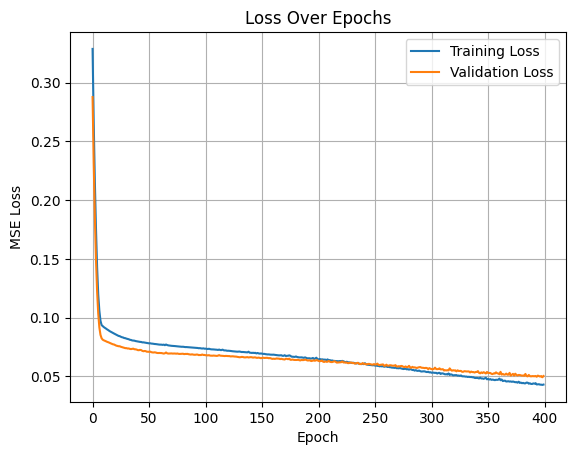

In [11]:
plt.plot(history_q4.history['loss'], label='Training Loss')
plt.plot(history_q4.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

## Q6: Plot the predicted values vs the target values for validation data

In [12]:
# predict
y_val_pred_scaled = model_q4.predict(X_val)

# unscale pred and target
y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled)

3/3 [==============================] - 0s 1ms/step


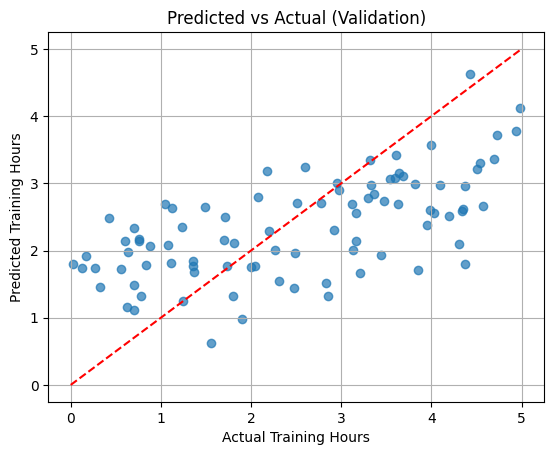

In [13]:
plt.scatter(y_val_raw, y_val_pred, alpha=0.7)
plt.plot([0, 5], [0, 5], 'r--') 
plt.xlabel('Actual Training Hours')
plt.ylabel('Predicted Training Hours')
plt.title('Predicted vs Actual (Validation)')
plt.grid(True)
plt.show()